<a href="https://colab.research.google.com/github/vugaer/ml-models/blob/main/session2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
import pandas as pd

In [37]:
df = pd.read_csv('15_9-23.csv')

In [38]:
df.head()

,WELL,DEPTH_MD,X_LOC,Y_LOC,Z_LOC,GROUP,FORMATION,CALI,RSHA,RMED,...,ROP,DTS,DCAL,DRHO,MUDWEIGHT,RMIC,ROPA,RXO,FORCE_2020_LITHOFACIES_LITHOLOGY,FORCE_2020_LITHOFACIES_CONFIDENCE
0,15/9-23,1518.280,433906.75,6460000.5,-1493.241821,HORDALAND GP.,Skade Fm.,15.506232,NaN,NaN,...,146.526276,326.451263,-1.993768,0.109706,NaN,NaN,88.968864,NaN,65000,3.0
1,15/9-23,1518.432,433906.75,6460000.5,-1493.393799,HORDALAND GP.,Skade Fm.,18.524611,NaN,NaN,...,147.605148,322.926361,1.024611,-0.006418,NaN,NaN,92.287186,NaN,65000,3.0
2,15/9-23,1518.584,433906.75,6460000.5,-1493.545776,HORDALAND GP.,Skade Fm.,18.855669,NaN,NaN,...,140.783127,325.283142,1.355668,0.022769,NaN,NaN,95.605499,NaN,65000,3.0
3,15/9-23,1518.736,433906.75,6460000.5,-1493.697754,HORDALAND GP.,Skade Fm.,19.163353,NaN,NaN,...,125.159531,334.233185,1.663353,0.024972,NaN,NaN,98.923820,NaN,65000,3.0
4,15/9-23,1518.888,433906.75,6460000.5,-1493.849609,HORDALAND GP.,Skade Fm.,18.489744,NaN,0.849849,...,107.576691,330.952362,0.989743,0.024527,NaN,NaN,102.242142,NaN,65000,3.0


In [39]:
df.columns

Index(['WELL', 'DEPTH_MD', 'X_LOC', 'Y_LOC', 'Z_LOC', 'GROUP', 'FORMATION',
       'CALI', 'RSHA', 'RMED', 'RDEP', 'RHOB', 'GR', 'SGR', 'NPHI', 'PEF',
       'DTC', 'SP', 'BS', 'ROP', 'DTS', 'DCAL', 'DRHO', 'MUDWEIGHT', 'RMIC',
       'ROPA', 'RXO', 'FORCE_2020_LITHOFACIES_LITHOLOGY',
       'FORCE_2020_LITHOFACIES_CONFIDENCE'],
      dtype='object')

In [41]:
df.isna().sum()

,0
WELL,0
DEPTH_MD,0
X_LOC,0
Y_LOC,0
Z_LOC,0
GROUP,0
FORMATION,0
CALI,0
RSHA,11063
RMED,54


In [42]:
df_cleaned = df.dropna(subset=['DEPTH_MD', 'CALI'])

In [45]:
X = df_cleaned['DEPTH_MD'].values.reshape(-1, 1)
y = df_cleaned['CALI'].values

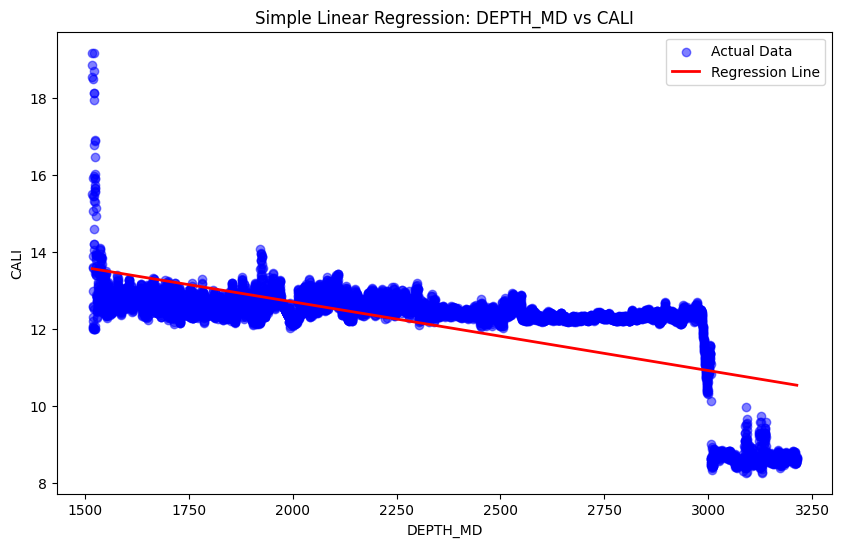

Intercept: 16.27
Coefficient (slope): -0.00


In [48]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Actual Data', alpha=0.5)
plt.plot(X, y_pred, color='red', linewidth=2, label='Regression Line')
plt.title('Simple Linear Regression: DEPTH_MD vs CALI')
plt.xlabel('DEPTH_MD')
plt.ylabel('CALI')
plt.legend()
plt.grid(False)
plt.show()

print(f"Intercept: {model.intercept_:.2f}")
print(f"Coefficient (slope): {model.coef_[0]:.2f}")

In [49]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y, y_pred)

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y, y_pred)

# Calculate R-squared (R2)
r2 = r2_score(y, y_pred)

# Print the metrics
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Squared Error (MSE): 0.98
Mean Absolute Error (MAE): 0.79
R-squared (R2): 0.44


In [50]:
from sklearn.preprocessing import StandardScaler

# Scale the data
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).flatten()

In [52]:
X_scaled

array([[-1.73104444],
       [-1.73073447],
       [-1.7304245 ],
       ...,
       [ 1.72355982],
       [ 1.72386979],
       [ 1.72417976]])

In [53]:
from sklearn.svm import SVR

model = SVR(kernel='rbf') # You can experiment with different kernels like 'linear', 'poly', 'rbf'
model.fit(X_scaled, y_scaled)
y_pred = model.predict(X_scaled)

In [55]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Calculate Mean Squared Error (MSE) for SVM
mse_svm = mean_squared_error(y_scaled, y_pred)

# Calculate Mean Absolute Error (MAE) for SVM
mae_svm = mean_absolute_error(y_scaled, y_pred)

# Calculate R-squared (R2) for SVM
r2_svm = r2_score(y_scaled, y_pred)

# Print the SVM metrics
print(f"SVM Mean Squared Error (MSE): {mse_svm:.2f}")
print(f"SVM Mean Absolute Error (MAE): {mae_svm:.2f}")
print(f"SVM R-squared (R2): {r2_svm:.2f}")

SVM Mean Squared Error (MSE): 0.13
SVM Mean Absolute Error (MAE): 0.21
SVM R-squared (R2): 0.87


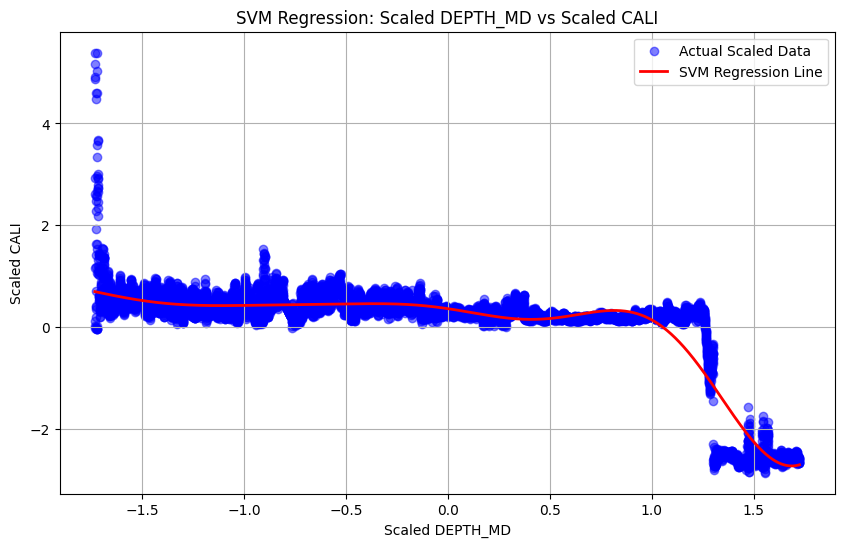

In [56]:
plt.figure(figsize=(10, 6))
plt.scatter(X_scaled, y_scaled, color='blue', label='Actual Scaled Data', alpha=0.5)
plt.plot(X_scaled, y_pred, color='red', linewidth=2, label='SVM Regression Line')
plt.title('SVM Regression: Scaled DEPTH_MD vs Scaled CALI')
plt.xlabel('Scaled DEPTH_MD')
plt.ylabel('Scaled CALI')
plt.legend()
plt.grid(True)
plt.show()